In [1]:
!pip install scikit-plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib, matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn import metrics

from scipy.stats import pearsonr

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

from itertools import cycle

import seaborn as sns
from seaborn import cubehelix_palette
sns.set()

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
def print_accuracy_and_classification_report(labels, prediction):
    print('Cross validation accuracy:')
    print('\t', metrics.accuracy_score(labels, prediction))
    print('\nCross validation classification report\n')
    print(metrics.classification_report(labels, prediction))

def predict_classes(probabilities):
    """Predict class labels from probabilities
    Args:
        probabilities (numpy.array): model output for each class
    Returns:
        (numpy.array): Model predicted class labels
    """
    predicted = np.array(
        [list(a).index(max(list(a))) for a in list(probabilities)])
    label_binarizer = preprocessing.LabelBinarizer()

    label_binarizer.fit(range(max(predicted) + 1))
    return label_binarizer.transform(predicted)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def dtree_grid_search(X,y,nfolds):
    #create a dictionary of all values we want to test
    param_grid = { 'criterion':['gini','entropy'],'max_depth': np.arange(3, 15)}
    # decision tree model
    dtree_model=DecisionTreeClassifier()
    #use gridsearch to test all values
    dtree_gscv = GridSearchCV(dtree_model, param_grid, cv=nfolds)
    #fit model to data
    dtree_gscv.fit(X, y)
    print(dtree_gscv.best_params_)
    return dtree_gscv.best_estimator_ 

In [5]:
df = pd.read_csv("data.csv", header=0, index_col=0)

In [6]:
df

,251986,259466,259456,261434,261433,250530,252807,252786,262034,233373,259438,234307,280385,266504,232941,232933,232936,259477,266512,266492,251858,251893,251894,250434,250331,252046,251938,250353,251831,251835,285886,259419,251817,232993,252048,250448,266562,252028,250332,232992,...,233783,280234,252876,261348,261539,250367,251899,250268,261330,251446,234163,286174,250363,286395,286771,251911,251909,252423,251917,261347,250663,259789,250597,266729,251926,252905,140397,216067,251833,252854,250270,250659,250607,234202,250636,250665,251132,252379,215797,class
Intensity_07,2.017779e+05,1.367139e+05,1.363392e+05,2.069761e+05,1.014679e+05,7.058152e+04,2.889535e+04,6.121650e+04,2.041364e+05,1.230924e+05,6.305567e+04,9.817941e+04,4.257481e+04,4.445461e+04,1.007480e+05,2.287629e+05,1.065165e+05,1.404583e+05,3.604857e+04,1.453842e+05,2.010778e+05,7.504582e+04,1.001742e+05,6.118545e+04,5.818048e+04,1.969018e+05,6.499775e+04,1.110478e+05,2.032405e+05,7.175199e+04,1.937935e+04,6.994071e+04,1.305923e+05,1.626294e+05,2.001647e+05,5.547840e+04,3.887391e+04,5.725637e+04,1.336977e+05,1.240097e+05,...,7.389400e+04,2.154256e+04,1.649194e+05,1.809906e+05,1.791808e+05,5.714762e+04,4.621782e+04,1.519819e+05,1.522112e+05,6.888848e+04,1.801741e+05,1.819019e+04,5.061877e+04,4.311361e+04,1.715878e+04,8.666039e+04,1.332832e+05,1.928640e+05,1.932377e+05,1.810644e+05,8.483860e+04,4.878274e+04,1.331909e+05,6.119286e+04,9.016635e+04,5.243871e+04,1.940435e+05,1.706226e+05,9.478536e+04,1.650116e+05,8.397116e+04,4.614863e+04,6.304457e+04,1.501605e+05,5.536254e+04,1.043062e+05,1.239052e+05,8.056557e+04,2.792765e+05,4.0
Intensity_08,4.544258e+04,3.924823e+04,4.477382e+04,8.558247e+04,1.080272e+05,7.503028e+04,2.295676e+05,2.212406e+04,1.080797e+05,1.338718e+05,1.822640e+05,1.072042e+05,2.284623e+07,2.282425e+04,1.303596e+05,1.579922e+05,1.303604e+05,1.820392e+05,7.845520e+04,1.317981e+05,6.714316e+04,5.733491e+04,2.352370e+05,4.014613e+04,5.505169e+04,2.120206e+05,1.552275e+04,3.550945e+04,2.218174e+05,4.004840e+04,3.295463e+05,1.818478e+05,4.839482e+04,4.129630e+04,4.089116e+04,3.623384e+04,1.323295e+05,5.736978e+04,3.160451e+04,8.256842e+04,...,1.439755e+05,1.568104e+07,2.165071e+05,3.673494e+04,3.824528e+04,3.548866e+04,2.363568e+04,5.014343e+04,4.024887e+04,2.754681e+05,2.216985e+05,1.106810e+06,4.767819e+04,6.715064e+05,4.732598e+05,2.467945e+05,2.466890e+05,3.261357e+04,2.474259e+05,3.633965e+04,5.715114e+04,1.852218e+05,5.902948e+04,3.002612e+04,2.299544e+05,4.280392e+04,2.123846e+05,2.577736e+05,2.477750e+05,1.032957e+05,2.951284e+05,4.206872e+04,2.900007e+05,5.404221e+04,3.044952e+04,6.214893e+04,4.004830e+04,1.683204e+05,1.278313e+05,4.0
Intensity_12,2.142579e+05,3.561582e+07,3.364496e+07,4.801287e+05,4.804064e+05,1.671702e+05,4.290248e+04,1.329199e+05,1.213322e+06,9.483727e+04,2.585692e+07,4.714728e+05,7.289463e+05,2.606468e+05,2.620580e+05,6.153192e+04,2.620155e+05,2.558236e+07,4.593395e+05,5.634939e+05,4.963066e+04,5.525112e+04,1.877704e+05,1.578562e+05,1.851856e+05,4.582586e+04,1.869238e+05,5.808694e+04,4.425251e+04,1.618165e+04,1.873408e+05,2.555131e+07,6.349721e+04,6.541382e+04,1.599352e+05,2.813377e+04,3.181173e+05,1.595893e+05,6.417813e+04,1.043743e+05,...,2.472055e+05,2.027375e+05,4.267246e+04,4.809303e+05,1.159565e+06,6.872062e+04,2.292549e+04,2.642592e+04,1.048059e+06,1.450338e+04,4.826804e+05,1.616965e+05,1.455949e+05,1.032492e+05,5.864489e+04,1.772376e+05,4.500303e+04,1.779093e+05,5.513232e+04,4.831940e+05,1.822154e+05,1.247263e+07,1.292821e+05,2.706596e+05,1.677396e+05,3.016953e+04,2.565100e+04,1.965793e+05,3.841555e+04,4.273812e+04,4.266227e+04,1.804167e+05,1.291606e+05,9.296261e+04,4.249112e+04,1.809004e+05,2.765589e+04,3.339945e+04,1.322575e+05,4.0
Intensity_18,4.087516e+03,7.331904e+05,6.811086e+05,3.599940e+05,5.191911e+05,8.468732e+05,3.797296e+07,3.579845e+07,1.748997e+05,1.456050e+05,6.826366e+05,3.398256e+04,3.027440e+04,1.437069e+05,3.960787e+04,1.474322e+05,1.474918e+05,2.492558e+05,1.245725e+05,1.391639e+05,4.386570e+03,4.0584

## Preprocessing 


In [7]:
from sklearn.model_selection import train_test_split


X = df.drop(columns = ['class'])
Y = df[['class']]

############# KBinsDiscretizer
from sklearn.preprocessing import KBinsDiscretizer  
# For GNB
# est_GNB = KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='uniform' 'quantile' 'kmeans)
est_GNB = KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='uniform')
X_GNB = est_GNB.fit_transform(X) 

# For DT
est = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='quantile')
X_DT = est.fit_transform(X) 


In [8]:
kfold = KFold(n_splits = 5, shuffle=True, random_state=42)

## Classification - Naive Bayes

In [9]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_GNB, Y, test_size=0.5, random_state=0)

In [10]:
enc = preprocessing.LabelEncoder()
Y_one_hot = enc.fit_transform(y_train_nb)
Y_test_labels = enc.transform(y_test_nb)

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:251: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb_fit = gnb.fit(X_train_nb, y_train_nb)
#nb_pred = cross_val_predict(gnb_fit, X_test_nb, y_test_nb, cv = kfold) #gnb_fit.predict(X_test_nb)
nb_train_score = cross_val_predict(gnb_fit, X_train_nb, Y_one_hot, cv = kfold, method='predict_proba') #dt_fit.predict(X_train_dt)
nb_y_score = cross_val_predict(gnb_fit, X_test_nb, Y_test_labels, cv = kfold, method='predict_proba') #dt_fit.predict_proba(X_test_dt)

/usr/local/lib/python3.6/dist-packages/sklearn/naive_bayes.py:206: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


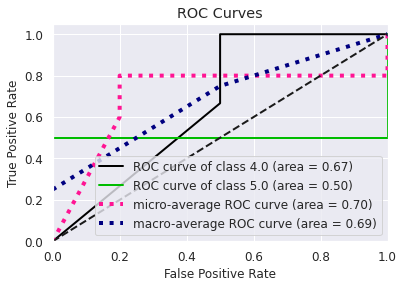

In [12]:
import scikitplot as skplt
skplt.metrics.plot_roc_curve(y_test_nb, nb_y_score)

[[3 0]
 [2 0]]


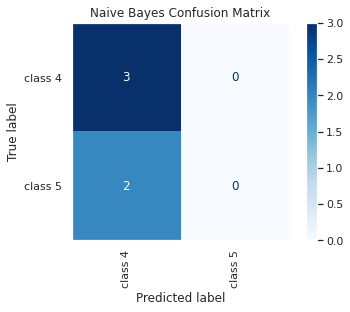

In [13]:
from sklearn.metrics import plot_confusion_matrix

class_names = ['class 4', 'class 5']

disp = plot_confusion_matrix(gnb, X_test_nb, y_test_nb,
                            display_labels = class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("Naive Bayes Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

In [14]:
print("***** Train Set *****")
print_accuracy_and_classification_report(Y_one_hot, predict_classes(nb_train_score))
print("****** Test Set ******")
print_accuracy_and_classification_report(Y_test_labels, predict_classes(nb_y_score))

***** Train Set *****
Cross validation accuracy:
	 0.4

Cross validation classification report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5

****** Test Set ******
Cross validation accuracy:
	 0.8

Cross validation classification report

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



## Classification - DT

In [15]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_DT, Y, test_size=0.5, random_state=0)

In [16]:
enc = preprocessing.LabelEncoder()
Y_one_hot = enc.fit_transform(y_train_dt)
Y_test_labels = enc.transform(y_test_dt)

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:251: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [47]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0)
dt_fit = clf.fit(X_train_dt, y_train_dt)
#dt_pred = cross_val_predict(dt_fit, X_test_dt, y_test_dt, cv = kfold) #dt_fit.predict(X_test_dt)
dt_train_score = cross_val_predict(dt_fit, X_train_dt, Y_one_hot, cv = kfold, method='predict_proba') #dt_fit.predict(X_train_dt)
dt_y_score = cross_val_predict(dt_fit, X_test_dt, Y_test_labels, cv = kfold, method='predict_proba') #dt_fit.predict_proba(X_test_dt)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


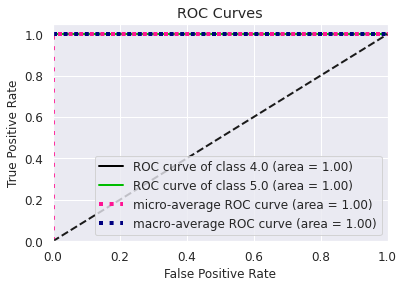

In [48]:
import scikitplot as skplt
skplt.metrics.plot_roc_curve(y_test_dt, dt_y_score)

[[1 2]
 [0 2]]


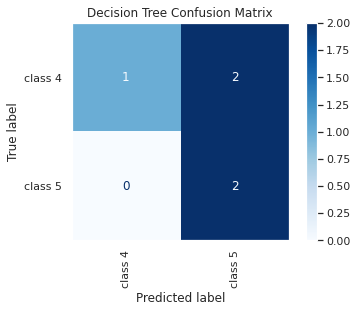

In [49]:
from sklearn.metrics import plot_confusion_matrix

class_names = ['class 4', 'class 5']

disp = plot_confusion_matrix(dt_fit, X_test_dt, y_test_dt,
                            display_labels = class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("Decision Tree Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

In [50]:
print("***** Train Set *****")
print_accuracy_and_classification_report(Y_one_hot, predict_classes(dt_train_score))
print("****** Test Set ******")
print_accuracy_and_classification_report(Y_test_labels, predict_classes(dt_y_score))

***** Train Set *****
Cross validation accuracy:
	 0.0

Cross validation classification report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       3.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0

****** Test Set ******
Cross validation accuracy:
	 1.0

Cross validation classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



## Feature importance

##### Naive Bayes

In [21]:
from sklearn.inspection import permutation_importance
results = permutation_importance(gnb_fit, X_train_nb, y_train_nb, scoring='accuracy')
gnb_importance = results.importances_mean

In [22]:
gnb_importance

array([-4.0000000e-02,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  4.0000000e-02,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
       -4.0000000e-02, -4.0000000e-02, -4.0000000e-02,  4.0000000e-02,
        4.0000000e-02,  4.4408921e-17, -4.0000000e-02,  4.0000000e-02,
       -4.0000000e-02, -4.0000000e-02, -4.0000000e-02,  0.0000000e+00,
       -4.0000000e-02,  0.0000000e+00, -4.0000000e-02,  4.0000000e-02,
        0.0000000e+00, -4.0000000e-02,  4.0000000e-02,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  4.0000000e-02,  0.0000000e+00,
        4.0000000e-02,  4.4408921e-17,  0.0000000e+00, -4.0000000e-02,
       -4.0000000e-02,  0.0000000e+00,  4.0000000e-02,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
      

In [23]:
gnb_feature_importances = pd.DataFrame(gnb_importance, index = X.columns, columns=['importance']).sort_values('importance', ascending=False) 
gnb_feature_importances = gnb_feature_importances[:10]

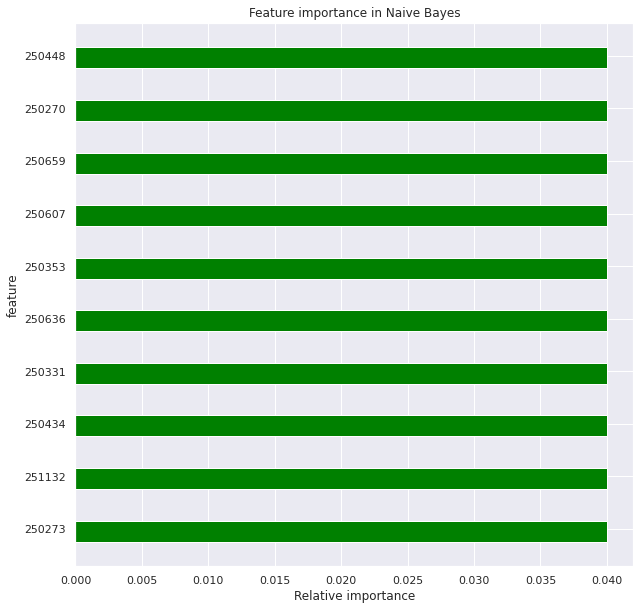

<Figure size 360x360 with 0 Axes>

In [24]:
import matplotlib. pyplot as plt
#modelname.feature_importance
x  = gnb_feature_importances.importance
col = gnb_feature_importances.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in Naive Bayes")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 10, forward=True)

##### Decision Tree

In [25]:
feature_importances = pd.DataFrame(dt_fit.feature_importances_, index = X.columns, columns=['importance']).sort_values('importance', ascending=False) 

feature_importances = feature_importances[:10]

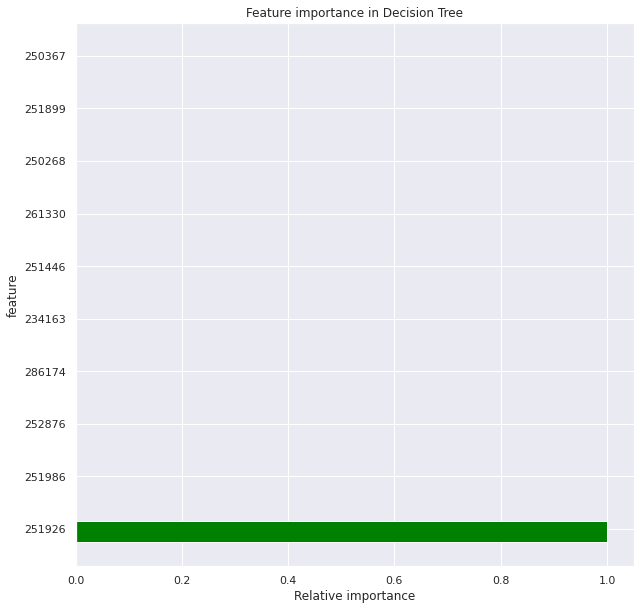

<Figure size 360x360 with 0 Axes>

In [26]:
import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances.importance
col = feature_importances.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in Decision Tree")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 10, forward=True)